# Real-World Applications (Speech, ECG, etc.)
Now that you've mastered the foundational concepts of signal processing, it's time to apply them to real-world signals, like speech, ECG, and machine vibrations.

### Learning Goals
- Load real signals (e.g., audio or biomedical)
- Apply techniques: FFT, filtering, smoothing, spectrograms
- Visualize and interpret real-world data

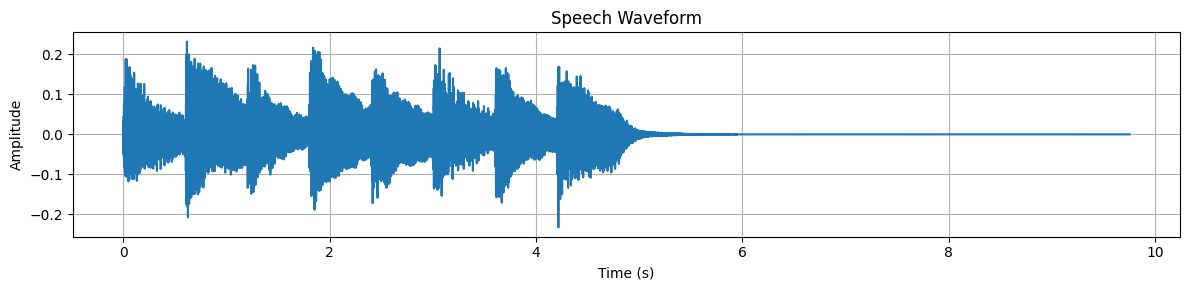

In [23]:
# Part 1: Load and Analyze a Speech Signal
# We'll use a .wav audio file.

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram

# Load WAV file (mono or stereo)
# 'data_Divisive_rhythm_in_4_4_time.wav' , "data_Circle_of_5th_chord_progression_minor.wav"  'data_BAK.wav'
file = 'data_Circle_of_5th_chord_progression_minor.wav' 
fs, data = wavfile.read(file)

# Normalize if needed
if data.dtype == np.int16:
    data = data / 32768.0  # 16-bit normalization
elif data.dtype == np.int32:
    data = data / 2147483648.0  # 32-bit

# Use only 1 channel if stereo
if data.ndim > 1:
    data = data[:, 0]

# Duration
t = np.linspace(0, len(data)/fs, num=len(data))

# Plot waveform
plt.figure(figsize=(12, 3))
plt.plot(t, data)
plt.title("Speech Waveform")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


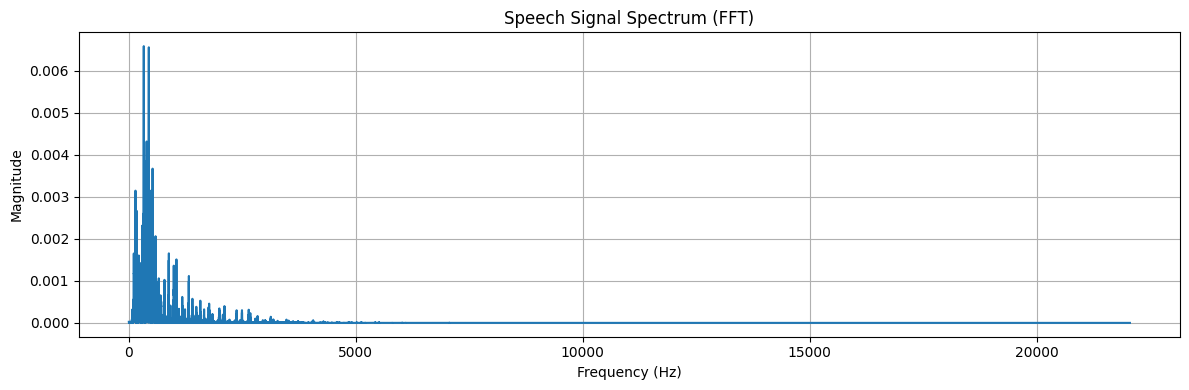

In [24]:
# Part 2: FFT of Speech

N = len(data)
xf = fftfreq(N, 1/fs)[:N//2]
yf = 2 * np.abs(fft(data))[:N//2] / N

plt.figure(figsize=(12, 4))
plt.plot(xf, yf)
plt.title("Speech Signal Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()


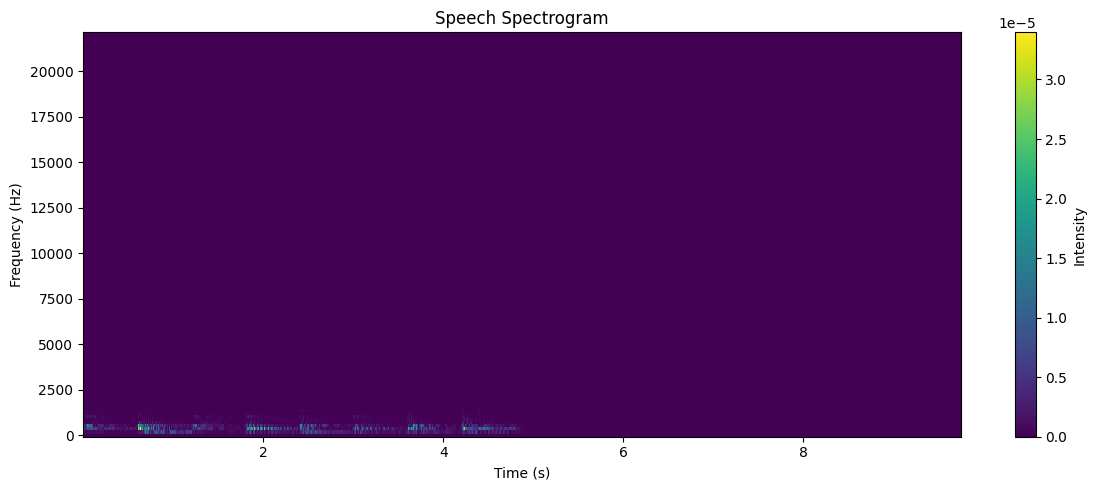

In [25]:
# Part 3: Spectrogram of Speech

f, tt, Sxx = spectrogram(data, fs)

plt.figure(figsize=(12, 5))
plt.pcolormesh(tt, f, Sxx, shading='nearest') # ['gouraud', 'nearest', 'flat', 'auto']
plt.title("Speech Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Intensity")
plt.tight_layout()
plt.show()


   Sample Value
0     -0.001622
1      0.002459
2      0.000177
3     -0.015121
4     -0.038852


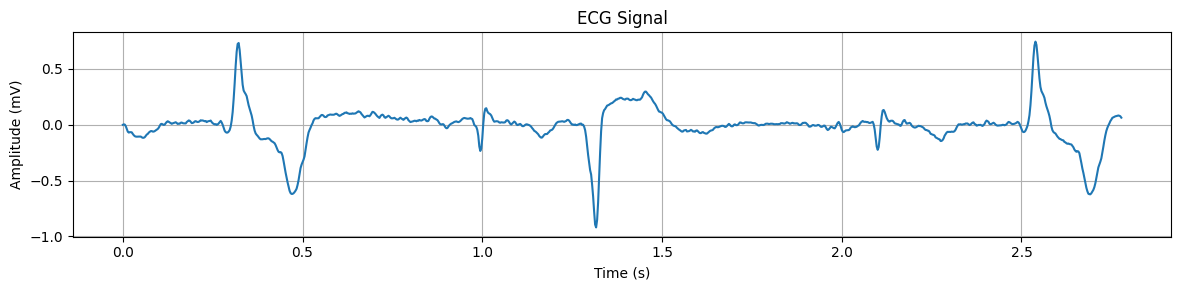

In [10]:
# Part 4: ECG Signal (Optional via wfdb or CSV)

import pandas as pd

# Example ECG from PhysioNet (or local CSV)
df = pd.read_csv("data_sample.csv") # sample_ecg.csv
print(df.head(5))
ecg = df['Sample Value'].values # ECG values
fs = 360  # Common ECG sampling rate
t = np.arange(len(ecg)) / fs

# Plot ECG
plt.figure(figsize=(12, 3))
plt.plot(t, ecg)
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.tight_layout()
plt.show()